<a href="https://colab.research.google.com/github/Zubair-471/GameForge3D/blob/master/notebooks/01_data_collection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GameForge3D — Phase 1: Data Collection & Preparation

**FYP 2026-2027 | NUML Dept. of Computer Science**  
**Supervisor:** Ms. Tooba Sagheer

**Steps:**
1. Mount Google Drive
2. Install Libraries
3. Download Cap3D captions CSV directly from HuggingFace
4. Filter gaming-relevant captions
5. Load & validate router_labels.csv
6. Train / Val / Test split
7. Visualize label distribution

## Step 1 — Mount Google Drive

In [9]:
from google.colab import drive
drive.mount('/content/drive')

import os
CHECKPOINT_DIR = '/content/drive/MyDrive/GameForge3D/checkpoints'
DATA_DIR       = '/content/drive/MyDrive/GameForge3D/data'

for d in [f'{CHECKPOINT_DIR}/router',
          f'{CHECKPOINT_DIR}/generator',
          f'{CHECKPOINT_DIR}/texture',
          DATA_DIR]:
    os.makedirs(d, exist_ok=True)

print('Drive mounted.')
print(f'Checkpoint dir: {CHECKPOINT_DIR}')
print(f'Data dir      : {DATA_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted.
Checkpoint dir: /content/drive/MyDrive/GameForge3D/checkpoints
Data dir      : /content/drive/MyDrive/GameForge3D/data


## Step 2 — Install Libraries

In [10]:
!pip install -q pandas scikit-learn matplotlib seaborn huggingface_hub
print('Libraries ready.')

Libraries ready.


## Step 3 — Download Cap3D Captions CSV from HuggingFace

Cap3D provides 785,000+ (uid, caption) pairs.  
We download the official captions CSV directly — no streaming API needed.

In [11]:
import pandas as pd
import os

CAP3D_LOCAL = '/content/Cap3D_captions.csv'
CAP3D_URL   = 'https://huggingface.co/datasets/tiange/Cap3D/resolve/main/Cap3D_automated_Objaverse_full.csv'

if not os.path.exists(CAP3D_LOCAL):
    print('Downloading Cap3D captions CSV (~50MB)...')
    import urllib.request
    urllib.request.urlretrieve(CAP3D_URL, CAP3D_LOCAL)
    print('Download complete.')
else:
    print('File already downloaded.')

df_cap3d = pd.read_csv(CAP3D_LOCAL, header=None, names=['uid', 'caption'])
print(f'Shape  : {df_cap3d.shape}')
print(f'Columns: {df_cap3d.columns.tolist()}')
df_cap3d.head()

File already downloaded.
Shape  : (1604291, 2)
Columns: ['uid', 'caption']


,uid,caption
0,yFocwO8x2UiIQYWxt2HtH1x1k,A stylized polearm weapon featuring a long sha...
1,r28vazrodBbLERkQIRq6awPtLd,"A white submarine, ship, spaceship, and airplane."
2,cw10X1QBD7aUnO3koOVMnif2s1,A small blue airplane.
3,5f8TCojZ7To8mT0EGgedy4aOaa,A low-poly blue pumpkin with a light green ste...
4,PrpNOs3jTfJWNbDJBakIqdDy5y,A mechanical assembly featuring a conical gray...


## Step 4 — Filter Gaming-Relevant Captions

Filter captions containing keywords for Weapon / Vehicle / Creature / Prop.

In [12]:
WEAPON_KW   = ['sword','axe','bow','gun','rifle','blade','dagger','spear',
               'lance','mace','cannon','pistol','crossbow','wand','staff',
               'knife','whip','shield','grenade','hammer','katana','saber']

VEHICLE_KW  = ['car','truck','bike','motorcycle','ship','boat','plane',
               'aircraft','submarine','tank','helicopter','spacecraft',
               'rover','chariot','vessel','train','bus','jet','mech']

CREATURE_KW = ['dragon','monster','creature','beast','wolf','zombie',
               'goblin','demon','ghost','skeleton','giant','fairy',
               'troll','vampire','golem','robot','alien','elemental',
               'dinosaur','griffin','phoenix','serpent']

PROP_KW     = ['barrel','chest','crate','lantern','bottle','table',
               'chair','door','fountain','altar','torch','key',
               'treasure','scroll','statue','pillar','ruin','cage',
               'pot','vase','throne','campfire','well']

ALL_KW = WEAPON_KW + VEHICLE_KW + CREATURE_KW + PROP_KW

# vectorized filter — very fast
pattern = '|'.join(ALL_KW)
mask    = df_cap3d['caption'].str.lower().str.contains(pattern, na=False)
df_gaming = df_cap3d[mask].reset_index(drop=True)

print(f'Total Cap3D samples : {len(df_cap3d):,}')
print(f'Gaming-relevant     : {len(df_gaming):,}')

df_gaming.to_csv(f'{DATA_DIR}/cap3d_gaming_subset.csv', index=False)
print(f'Saved: {DATA_DIR}/cap3d_gaming_subset.csv')
df_gaming.head(10)

Total Cap3D samples : 1,604,291
Gaming-relevant     : 420,921
Saved: /content/drive/MyDrive/GameForge3D/data/cap3d_gaming_subset.csv


,uid,caption
0,yFocwO8x2UiIQYWxt2HtH1x1k,A stylized polearm weapon featuring a long sha...
1,r28vazrodBbLERkQIRq6awPtLd,"A white submarine, ship, spaceship, and airplane."
2,cw10X1QBD7aUnO3koOVMnif2s1,A small blue airplane.
3,5f8TCojZ7To8mT0EGgedy4aOaa,A low-poly blue pumpkin with a light green ste...
4,PrpNOs3jTfJWNbDJBakIqdDy5y,A mechanical assembly featuring a conical gray...
5,9BDqBnkJeEjeQ4o68xhCSOHTP8,A WWII fighter plane.
6,UErNeoO2YxmiFhF0Jjpsipwc1C,A white microwave oven with a partially open d...
7,kiDgUIcaC7c4YaIcLCJeq4kS7rK,A white single-engine propeller airplane with ...
8,2eOt2Co4yuPfsD9trHxSmIuxwgK,"A green, frog-like creature wearing round glas..."
9,dZM64cBYmcGvXfIPfctL7VYthzj,A dump truck.


## Step 5 — Load & Validate router_labels.csv from GitHub

In [13]:
import subprocess, os, shutil

REPO_PATH = '/content/GameForge3D'

# Always remove and re-clone to avoid stale state from interrupted runs
if os.path.exists(REPO_PATH):
    shutil.rmtree(REPO_PATH)
    print('Removed old folder.')

subprocess.run(['git', 'clone',
                'https://github.com/Zubair-471/GameForge3D.git',
                REPO_PATH], check=True)
print('Repo cloned fresh.')

ROUTER_CSV = f'{REPO_PATH}/data/router_labels.csv'
df_router  = pd.read_csv(ROUTER_CSV)

print(f'Router dataset shape : {df_router.shape}')
print('\nLabel distribution:')
print(df_router['label'].value_counts())

Removed old folder.
Repo cloned fresh.
Router dataset shape : (425, 2)

Label distribution:
label
Creature    110
Prop        110
Weapon      105
Vehicle     100
Name: count, dtype: int64


## Step 6 — Train / Val / Test Split (70 / 15 / 15)

In [14]:
from sklearn.model_selection import train_test_split

df_trainval, df_test = train_test_split(
    df_router, test_size=0.15, random_state=42, stratify=df_router['label'])

df_train, df_val = train_test_split(
    df_trainval, test_size=0.176, random_state=42, stratify=df_trainval['label'])

print(f'Train : {len(df_train)}')
print(f'Val   : {len(df_val)}')
print(f'Test  : {len(df_test)}')

df_train.to_csv(f'{DATA_DIR}/router_train.csv', index=False)
df_val.to_csv(  f'{DATA_DIR}/router_val.csv',   index=False)
df_test.to_csv( f'{DATA_DIR}/router_test.csv',  index=False)
print(f'Splits saved to {DATA_DIR}')

Train : 297
Val   : 64
Test  : 64
Splits saved to /content/drive/MyDrive/GameForge3D/data


## Step 7 — Label Distribution Chart

/tmp/ipykernel_617/3460563920.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=ax, palette='viridis')
/tmp/ipykernel_617/3460563920.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=ax, palette='viridis')
/tmp/ipykernel_617/3460563920.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=ax, palette='viridis')


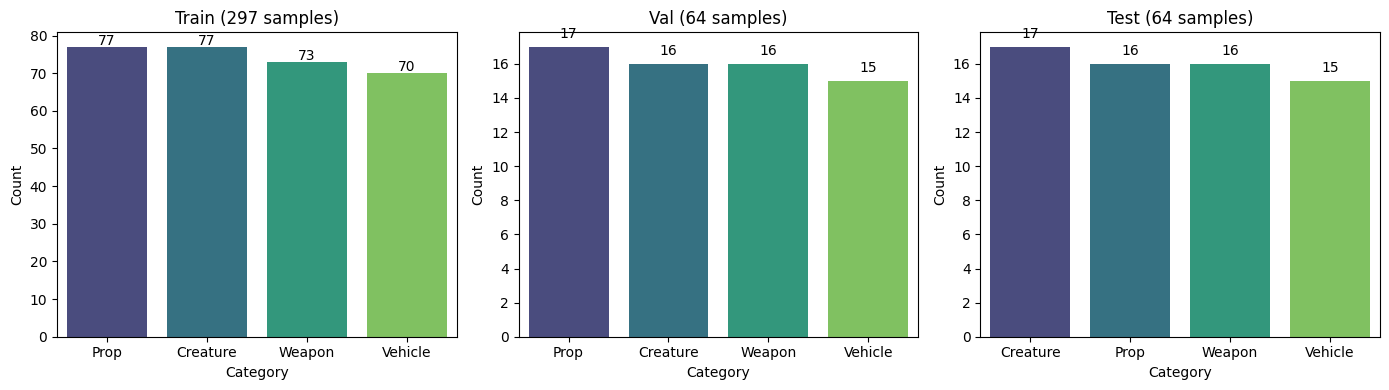

Chart saved.


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
splits_dict = {'Train': df_train, 'Val': df_val, 'Test': df_test}

for ax, (name, df) in zip(axes, splits_dict.items()):
    counts = df['label'].value_counts()
    sns.barplot(x=counts.index, y=counts.values, ax=ax, palette='viridis')
    ax.set_title(f'{name} ({len(df)} samples)')
    ax.set_xlabel('Category')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 0.5, str(v), ha='center')

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/label_distribution.png', dpi=150)
plt.show()
print('Chart saved.')

## Phase 1 Complete! ✅

| Output | Location |
|--------|----------|
| Cap3D Gaming Subset | `data/cap3d_gaming_subset.csv` |
| Router Train | `data/router_train.csv` |
| Router Val | `data/router_val.csv` |
| Router Test | `data/router_test.csv` |
| Label Chart | `data/label_distribution.png` |

**Next → Phase 2: Asset Category Router (DistilBERT fine-tuning)**